# AIM · 1주차 실습
## CNN ① 이미지에서 패턴 찾기

**대상:** Python·PyTorch 기초 이수자 / **권장:** Google Colab Python 3, GPU 선택 가능.

Python, 텐서, nn.Module, 역전파 기초를 전제로 한다. FashionMNIST 다운로드를 수업 전에 완료한다. 실습 기본값은 일부 학습 데이터와 짧은 학습이며 목표는 최고 정확도보다 올바른 파이프라인이다.

### 학습 목표
- 합성곱의 출력 크기와 파라미터 수를 계산한다.
- FashionMNIST 분류기를 구현하고 학습을 진단한다.
- 특징 맵과 오분류를 근거로 모델의 한계를 설명한다.

### 실행 방법
1. Colab에서 `파일 → 노트북 업로드`로 이 파일을 엽니다.
2. GPU를 사용할 경우 `런타임 → 런타임 유형 변경`에서 GPU를 선택합니다.
3. 위에서 아래로 셀을 실행합니다. 이전 주차 파일이나 별도 Python 모듈은 필요 없습니다.
4. Colab 기본 torch·torchvision을 우선 사용합니다. import가 실패하면 새 런타임에서 시작하세요.
   로컬 환경은 루트 `환경설정.md`를 참고하세요. 데이터 최초 다운로드에는 인터넷이 필요합니다.
5. 학습이 길면 `TRAIN_N`, `EPOCHS` 또는 `STEPS`를 줄입니다. 작은 실험의 품질은 보장되지 않습니다.

**시간 운영:** 실습 셀 번호가 아니라 아래 § 구간으로 진행합니다. 준비·다운로드는 수업 시작에,
핵심 실행은 50–75분에, 관찰 답변은 75–85분에 수행합니다. 심화와 자율 과제는 수업 밖에서 진행합니다.

**재현성:** 고정 seed도 다른 GPU·라이브러리 버전의 완전히 같은 수치를 보장하지 않습니다.
실제 출력과 예측을 구분해 기록하세요. `outputs/`는 현재 실행 폴더에 생성됩니다.

## §1 · 환경 확인

첫 실행에서 버전과 device를 확인합니다. CPU도 지원하며 설치가 필요한 경우 환경설정 문서를 먼저 읽습니다.

In [1]:
import os, sys, math, random, copy, time, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from IPython.display import display

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# QUICK=True: 수업용 일부 데이터. False: 데이터/학습 예산 확대.
QUICK = True
# 검증 제작자용 축소 모드. 수강생은 설정할 필요가 없습니다.
SMOKE = os.environ.get('AIM_SMOKE', '0') == '1'
DATA_ROOT = Path(os.environ.get('AIM_DATA_ROOT', './data'))
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
torch.set_num_threads(min(4, os.cpu_count() or 1))

def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_all()
print('Python', sys.version.split()[0], '| torch', torch.__version__,
      '| torchvision', torchvision.__version__, '| device', DEVICE)
print('QUICK:', QUICK, '| SMOKE:', SMOKE, '| data:', DATA_ROOT.resolve())

def image_grid(images, titles=None, cols=8, title='', normalized=False):
    images = images.detach().cpu()
    if normalized: images = (images * .5 + .5).clamp(0, 1)
    n = len(images); rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.35, rows*1.55), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            im = images[i]
            ax.imshow(im.squeeze(0) if im.shape[0]==1 else im.permute(1,2,0),
                      cmap='gray', vmin=0, vmax=1)
            if titles is not None: ax.set_title(str(titles[i]), fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    return fig

def num_params(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)

def cpu_state(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

Python 3.13.9 | torch 2.14.0+cpu | torchvision 0.29.0+cpu | device cpu
QUICK: True | SMOKE: False | data: D:\AIM\.study-data


In [2]:
DATASET = 'fashion'
TRAIN_N = 256 if SMOKE else (4096 if QUICK else 40000)
VAL_N = 128 if SMOKE else (1024 if QUICK else 5000)
TEST_N = 128 if SMOKE else (1024 if QUICK else 10000)
BATCH = 64 if SMOKE else 128
EPOCHS = 1 if SMOKE else (3 if QUICK else 15)

## §2 · 데이터와 분할

공식 train을 고정 인덱스로 나누고 test는 마지막에만 사용합니다. QUICK의 평가 숫자는 전체 공식 test의 성능이 아닌 고정 부분집합 성능입니다. MNIST 계열은 0~1, CIFAR10만 -1~1로 변환합니다.

split sizes: 4096 1024 1024
shape: torch.Size([128, 1, 28, 28]) dtype: torch.float32 range: (0.0, 1.0)


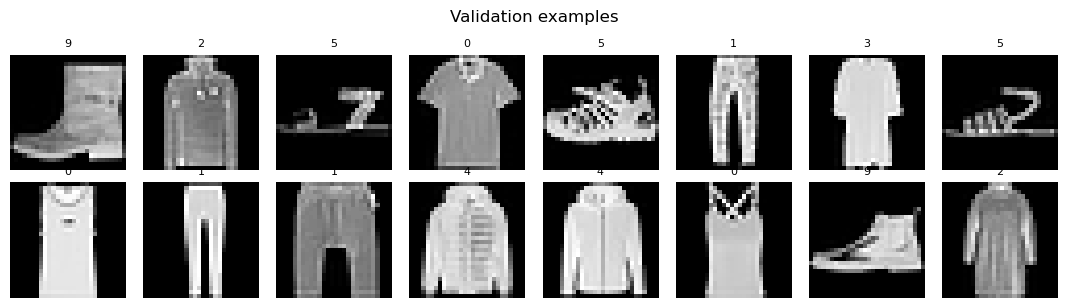

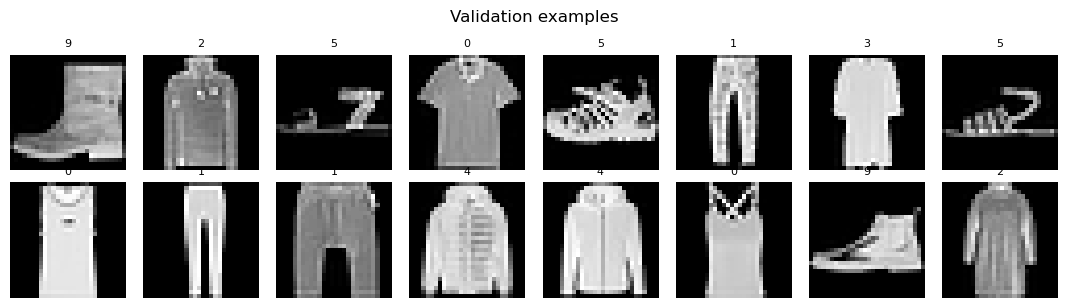

In [3]:
# DATASET은 앞의 설정 셀에서 지정합니다.train/valは公式trainから分割。
def vision_loaders(name, augment=False):
    cls = {'fashion':datasets.FashionMNIST, 'cifar':datasets.CIFAR10, 'mnist':datasets.MNIST}[name]
    base = [transforms.ToTensor()]
    if name=='cifar': base += [transforms.Normalize((.5,)*3, (.5,)*3)]
    eval_tf = transforms.Compose(base)
    train_tf = transforms.Compose(([transforms.RandomCrop(32,padding=4),
                                    transforms.RandomHorizontalFlip()] if augment else []) + base)
    train_ds = cls(DATA_ROOT, train=True, download=True, transform=train_tf)
    val_ds = cls(DATA_ROOT, train=True, download=True, transform=eval_tf)
    test_ds = cls(DATA_ROOT, train=False, download=True, transform=eval_tf)
    ids = torch.randperm(len(train_ds), generator=torch.Generator().manual_seed(SEED))
    n_val = 5000 if name=='cifar' else 6000
    train_ids = ids[n_val:][:TRAIN_N].tolist()
    val_ids = ids[:n_val][:VAL_N].tolist()
    test_ids = torch.randperm(len(test_ds), generator=torch.Generator().manual_seed(SEED+1))[:TEST_N].tolist()
    assert not (set(train_ids) & set(val_ids))
    train = DataLoader(Subset(train_ds,train_ids), batch_size=BATCH, shuffle=True,
                       generator=torch.Generator().manual_seed(SEED), num_workers=0)
    val = DataLoader(Subset(val_ds,val_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    test = DataLoader(Subset(test_ds,test_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    return train,val,test

train_loader, val_loader, test_loader = vision_loaders(DATASET)
xb,yb = next(iter(val_loader))
print('split sizes:', *(len(dl.dataset) for dl in [train_loader,val_loader,test_loader]))
print('shape:', xb.shape, 'dtype:', xb.dtype, 'range:', (xb.min().item(),xb.max().item()))
image_grid(xb[:16], yb[:16].tolist(), title='Validation examples', normalized=DATASET=='cifar')

## §3 · 분류 모델 정의

모델 코드의 각 층 옆에 입출력 shape를 손으로 적어 보세요. MLP/SmallCNN은 FashionMNIST용, CifarCNN은 컬러 이미지용입니다.

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(),nn.Linear(784,128),nn.ReLU(),nn.Linear(128,10))
    def forward(self,x): return self.net(x)

class SmallCNN(nn.Module):
    def __init__(self,width=16,kernel=3):
        super().__init__()
        assert kernel % 2 == 1
        self.features=nn.Sequential(
            nn.Conv2d(1,width,kernel,padding=kernel//2),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(width,width*2,kernel,padding=kernel//2),nn.ReLU(),nn.MaxPool2d(2))
        self.classifier=nn.Sequential(nn.Flatten(),nn.Linear(width*2*7*7,64),nn.ReLU(),nn.Linear(64,10))
    def forward(self,x): return self.classifier(self.features(x))

class ResidualBlock(nn.Module):
    def __init__(self,cin,cout,stride=1):
        super().__init__()
        self.body=nn.Sequential(nn.Conv2d(cin,cout,3,stride,1,bias=False),nn.BatchNorm2d(cout),nn.ReLU(),
                                nn.Conv2d(cout,cout,3,1,1,bias=False),nn.BatchNorm2d(cout))
        self.skip=nn.Identity() if cin==cout and stride==1 else nn.Sequential(
            nn.Conv2d(cin,cout,1,stride,bias=False),nn.BatchNorm2d(cout))
    def forward(self,x): return F.relu(self.body(x)+self.skip(x))

class CifarCNN(nn.Module):
    def __init__(self,residual=False):
        super().__init__()
        layers=[nn.Conv2d(3,32,3,padding=1,bias=False),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2)]
        if residual: layers += [ResidualBlock(32,64,stride=2)]
        else: layers += [nn.Conv2d(32,64,3,padding=1,bias=False),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2)]
        self.features=nn.Sequential(*layers,nn.AdaptiveAvgPool2d(1))
        self.head=nn.Linear(64,10)
    def forward(self,x): return self.head(self.features(x).flatten(1))

## §4 · 공통 학습·평가 함수

샘플 수 가중 평균, eval/no_grad, 최고 validation checkpoint 복사를 확인합니다.

In [5]:
def classification_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training); total=correct=count=0
    all_y=[]; all_pred=[]
    with torch.set_grad_enabled(training):
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            logits=model(x); loss=F.cross_entropy(logits,y)
            assert torch.isfinite(loss), 'loss is not finite'
            if training: loss.backward(); optimizer.step()
            n=len(y); total+=loss.item()*n; count+=n
            pred=logits.argmax(1); correct+=(pred==y).sum().item()
            all_y.append(y.detach().cpu()); all_pred.append(pred.detach().cpu())
    return dict(loss=total/count,accuracy=correct/count,
                y=torch.cat(all_y),pred=torch.cat(all_pred))

def fit_classifier(factory,loader,epochs=EPOCHS):
    seed_all(); model=factory().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
    history=[]; best_loss=float('inf'); best=None; start=time.perf_counter()
    for ep in range(epochs):
        tr=classification_epoch(model,loader,opt); va=classification_epoch(model,val_loader)
        history.append(dict(epoch=ep+1,train_loss=tr['loss'],val_loss=va['loss'],val_acc=va['accuracy']))
        if va['loss']<best_loss: best_loss=va['loss']; best=cpu_state(model)
        print(f"epoch {ep+1}: train={tr['loss']:.3f} val={va['loss']:.3f} acc={va['accuracy']:.3f}")
    model.load_state_dict(best)
    return model,history,time.perf_counter()-start

def plot_classification(histories):
    fig,axes=plt.subplots(1,2,figsize=(10,3))
    for name,h in histories.items():
        axes[0].plot([r['epoch'] for r in h],[r['train_loss'] for r in h],label=name+' train')
        axes[0].plot([r['epoch'] for r in h],[r['val_loss'] for r in h],'--',label=name+' val')
        axes[1].plot([r['epoch'] for r in h],[r['val_acc'] for r in h],label=name)
    axes[0].set_title('Cross entropy'); axes[1].set_title('Validation accuracy')
    for ax in axes: ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=.2)
    plt.tight_layout(); plt.show()

def confusion(y,pred,nclass=10):
    return torch.bincount(y*nclass+pred,minlength=nclass*nclass).reshape(nclass,nclass)

def inspect_classifier(model):
    result=classification_epoch(model,val_loader)
    cm=confusion(result['y'],result['pred'])
    fig,ax=plt.subplots(figsize=(5,4)); im=ax.imshow(cm,cmap='Blues')
    ax.set(xlabel='predicted',ylabel='true',xticks=range(10),yticks=range(10))
    fig.colorbar(im,ax=ax); plt.show()
    recall=cm.diag().float()/cm.sum(1).clamp_min(1)
    print('class counts:',cm.sum(1).tolist()); print('recall:',recall.tolist())
    wrong=(result['y']!=result['pred']).nonzero().flatten()[:8]
    if len(wrong):
        imgs=torch.stack([val_loader.dataset[i.item()][0] for i in wrong])
        labels=[f"true={result['y'][i]} pred={result['pred'][i]}" for i in wrong]
        image_grid(imgs,labels,title='Validation errors',normalized=DATASET=='cifar')
    else: print('No error in this validation subset; inspect a larger subset.')
    return cm

## §3-검사 · 합성곱 손계산

출력을 실행하기 전에 계산하세요. bias=1을 포함해야 합니다.

In [6]:
patch=torch.tensor([[[[1.,2.],[3.,4.]]]])
kernel=torch.tensor([[[[1.,0.],[0.,-1.]]]])
result=F.conv2d(patch,kernel,bias=torch.tensor([1.]))
assert result.item()==-2
print('manual convolution:',result.item())
model=SmallCNN(); x=torch.zeros(2,1,28,28)
for layer in model.features:
    x=layer(x); print(type(layer).__name__,tuple(x.shape))
assert x.flatten(1).shape[1]==1568
assert model(torch.zeros(2,1,28,28)).shape==(2,10)
print('MLP params:',num_params(MLP()),'CNN params:',num_params(model))

manual convolution: -2.0
Conv2d (2, 16, 28, 28)
ReLU (2, 16, 28, 28)
MaxPool2d (2, 16, 14, 14)
Conv2d (2, 32, 14, 14)
ReLU (2, 32, 14, 14)
MaxPool2d (2, 32, 7, 7)
MLP params: 101770 CNN params: 105866


**관찰·토론**

Flatten을 하면 왜 1,568차원인가요? MLP와 CNN의 파라미터 수가 다르다는 점은 비교 해석에 어떤 영향을 주나요?

## §5 · MLP와 CNN 학습

학습 시작 전에 val loss가 어떻게 바뀔지 예측합니다. 두 모델 모두 같은 분할과 epoch 예산을 사용합니다.

epoch 1: train=1.370 val=0.913 acc=0.680
epoch 2: train=0.772 val=0.747 acc=0.724
epoch 3: train=0.642 val=0.660 acc=0.770
epoch 1: train=1.719 val=1.019 acc=0.598
epoch 2: train=0.854 val=0.811 acc=0.720
epoch 3: train=0.707 val=0.682 acc=0.755


[{'model': 'MLP',
  'params': 101770,
  'seconds': 0.48,
  'val_loss': 0.6598436459898949,
  'val_acc': 0.76953125},
 {'model': 'CNN',
  'params': 105866,
  'seconds': 1.53,
  'val_loss': 0.6819252446293831,
  'val_acc': 0.7548828125}]

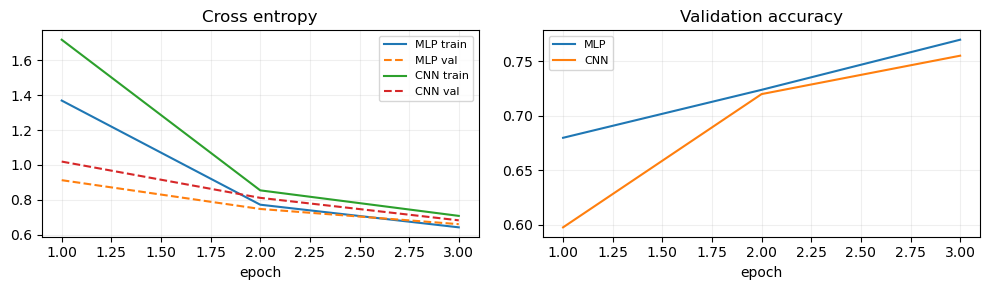

272

In [7]:
models={}; histories={}; rows=[]
for name,factory in [('MLP',MLP),('CNN',SmallCNN)]:
    train_loader.generator.manual_seed(SEED)
    m,h,seconds=fit_classifier(factory,train_loader)
    models[name]=m; histories[name]=h
    r=classification_epoch(m,val_loader)
    rows.append(dict(model=name,params=num_params(m),seconds=round(seconds,2),val_loss=r['loss'],val_acc=r['accuracy']))
display(rows); plot_classification(histories)
(OUT/'cnn_comparison.json').write_text(json.dumps(rows,indent=2))

**관찰·토론**

CNN이 더 좋았나요? 아니라면 학습 예산, 모델 크기, 초기화 중 무엇을 먼저 추가 확인하겠나요?

## §6 · CNN의 실패 사례와 특징 맵

분석은 validation에서 수행합니다. 특징 맵은 활성화이며 인과적 중요도 지도가 아닙니다.

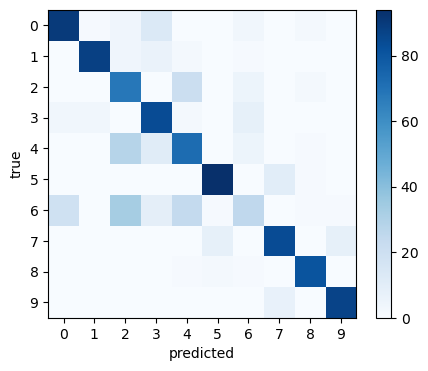

class counts: [113, 101, 96, 100, 117, 105, 113, 100, 85, 94]
recall: [0.7964601516723633, 0.8712871074676514, 0.7083333134651184, 0.8399999737739563, 0.6153846383094788, 0.8952381014823914, 0.22123894095420837, 0.8399999737739563, 0.9529411792755127, 0.9255319237709045]


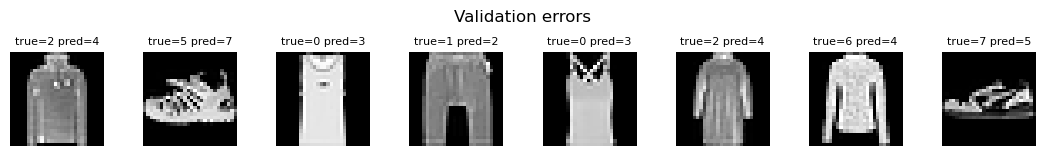

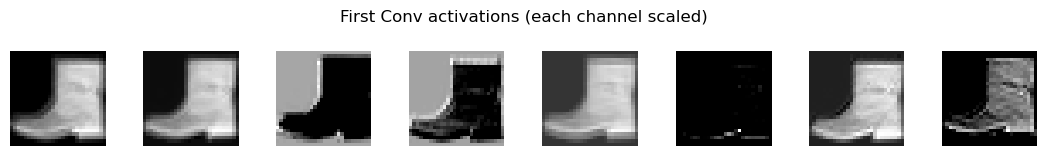

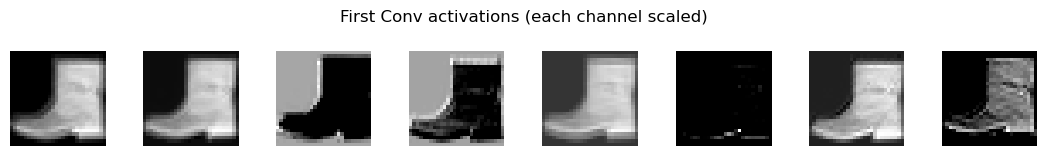

In [8]:
cnn=models['CNN']; cm=inspect_classifier(cnn)
cnn.eval()
with torch.no_grad():
    sample=next(iter(val_loader))[0][:1].to(DEVICE)
    activation=F.relu(cnn.features[0](sample))[0,:8].unsqueeze(1)
image_grid(activation / activation.amax((2,3),keepdim=True).clamp_min(1e-6),title='First Conv activations (each channel scaled)')

**관찰·토론**

가장 많이 혼동된 클래스 쌍을 찾고 실제 이미지 2개로 가능한 이유를 설명하세요. 채널별 정규화 때문에 밝기를 채널 간 직접 비교할 수 있을까요?

## §7 · 모델 선택 후 test 한 번

val loss로 조건을 선택합니다. test를 본 뒤 설정을 바꾸면 새로운 검증 절차가 필요합니다.

In [9]:
chosen=min(rows,key=lambda r:r['val_loss'])['model']
final=classification_epoch(models[chosen],test_loader)
print('selected:',chosen,'| test subset loss:',final['loss'],'| accuracy:',final['accuracy'])
torch.save({'state_dict':cpu_state(models[chosen]),'model_name':chosen,'seed':SEED},OUT/'classifier.pt')

selected: MLP | test subset loss: 0.6450001895427704 | accuracy: 0.771484375


## 실험 기록표 · 직접 작성

| 항목 | 기록 |
|---|---|
| 가설 / 바꿀 변수 | |
| 고정한 분할·seed·학습 예산 | |
| 실제 관측 지표와 그림 | |
| 예상과 다른 점 | |
| 가능한 이유 2가지 | |
| 한계와 다음 실험 | |

## 출구 확인

PPT 출구 퀴즈에 답한 뒤, 오늘 모델의 **입력 → 중간 표현 → 출력 → loss → 평가**를 다섯 줄로 적으세요.
자율 과제는 `homework_optional.ipynb`, 리더 참고 구현은 `leader_solution.ipynb`입니다.

## 출처 및 추가 읽기

- [PyTorch · 이미지 분류 튜토리얼](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)
- [Conv2d · 공식 API](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [Deep Residual Learning · He et al.](https://arxiv.org/abs/1512.03385)

모든 설명용 코드와 도식은 수업용으로 새로 작성했습니다. 외부 원문 코드를 그대로 복제하지 않았습니다.